In [36]:
import pandas as pd

# Read csv wich is compress with gzip

df = pd.read_csv("data/GSE266566_COUNTS.rsem_human.transcripts_NRP1_KD_BrCa_llynam.txt.gz", compression="gzip", sep="\t")

In [37]:
df

,Ensembl.114.Transcript.ID,Ensembl.114.Transcript.Name,Ensembl.114.Transcript.Type,counts.HS578T.shNRP1.3.RNA.1,counts.HS578T.shNRP1.3.RNA.2,counts.HS578T.shNRP1.5.RNA.1,counts.HS578T.shNRP1.5.RNA.2,counts.HS578T.shNRP1.5.RNA.3,counts.HS578T.shNT.RNA.1,counts.HS578T.shNT.RNA.2,...,counts.SUM159.shNT.RNA.2,counts.SUM159.shNT.RNA.3,counts.SUM159.siNRP1.3.RNA.1,counts.SUM159.siNRP1.3.RNA.2,counts.SUM159.siNRP1.3.RNA.3,counts.SUM159.siNRP1.5.RNA.2,counts.SUM159.siNRP1.5.RNA.3,counts.SUM159.siNT.RNA.1,counts.SUM159.siNT.RNA.2,counts.SUM159.siNT.RNA.3
0,ENST00000373020.9,TSPAN6-201,protein_coding,1380.55,1125.04,1800.12,1431.07,1954.82,1565.45,448.91,...,854.43,1410.21,779.00,861.76,955.89,1037.81,1632.17,1128.66,1126.10,919.09
1,ENST00000494424.1,TSPAN6-202,protein_coding_CDS_not_defined,7.94,0.00,10.54,0.00,26.52,15.63,80.82,...,0.00,0.00,0.00,33.25,0.00,45.12,25.88,22.28,7.39,15.16
2,ENST00000496771.5,TSPAN6-203,protein_coding_CDS_not_defined,63.50,70.78,96.34,123.93,110.51,83.92,27.01,...,70.56,118.71,0.00,19.64,59.11,34.07,229.95,13.05,44.52,30.75
3,ENST00000612152.4,TSPAN6-204,protein_coding,0.00,3.17,0.00,0.00,6.15,0.00,3.26,...,3.01,3.07,0.00,3.34,0.00,0.00,0.00,0.00,0.00,0.00
4,ENST00000373031.5,TNMD-201,protein_coding,0.00,0.00,3.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387949,ENST00000409293.6,FAM174C-202,protein_coding,2112.79,2898.21,2190.88,3172.34,3628.42,1887.85,2322.25,...,1855.27,2443.60,819.95,715.68,1030.17,1383.23,3608.68,940.76,1189.30,1145.26
387950,ENST00000485191.5,FAM174C-203,retained_intron,145.72,234.71,116.32,271.73,556.50,124.48,171.24,...,110.80,125.98,59.49,43.98,93.19,76.87,202.85,51.44,76.18,61.60
387951,ENST00000585716.3,FAM174C-204,protein_coding_CDS_not_defined,0.00,0.00,0.00,0.00,15.20,0.00,22.75,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
387952,ENST00000590269.2,FAM174C-205,protein_coding_CDS_not_defined,7.58,30.88,10.41,37.90,59.85,14.46,17.42,...,1.54,0.00,0.00,5.95,1.63,2.77,0.00,0.00,2.66,1.31


In [38]:
df.set_index("Ensembl.114.Transcript.Name", inplace=True)

# Ceux qui "shNT" sont les échantillons de contrôle, les autres sont les échantillons de knockdown de siNRP1
# count.<lignee> donnne la lignée de chaque échantillon

# Remove the two first columns
df = df.iloc[:, 2:]
df = df.T


# Crée un nouveau dataframe  <Lignée> et <knockdown> (Oui/Non) à partir du nom de l'échantillon
meta = pd.DataFrame(index=df.index)
meta["Lignée"] = df.index.str.split(".").str[1]
meta["knockdown"] = df.index.str.contains("shNT")
meta

,Lignée,knockdown
counts.HS578T.shNRP1.3.RNA.1,HS578T,False
counts.HS578T.shNRP1.3.RNA.2,HS578T,False
counts.HS578T.shNRP1.5.RNA.1,HS578T,False
counts.HS578T.shNRP1.5.RNA.2,HS578T,False
counts.HS578T.shNRP1.5.RNA.3,HS578T,False
counts.HS578T.shNT.RNA.1,HS578T,True
counts.HS578T.shNT.RNA.2,HS578T,True
counts.HS578T.shNT.RNA.3,HS578T,True
counts.HS578T.siNRP1.3.RNA.1,HS578T,False
counts.HS578T.siNRP1.3.RNA.2,HS578T,False


In [39]:
import numpy as np

# Normalize the data with log2 transformation
df_log2 = np.log2(df + 1)
df_log2

# Remove columns with zero variance
df_log2 = df_log2.loc[:, df_log2.var() > 0]
df_log2

Ensembl.114.Transcript.Name,TSPAN6-201,TSPAN6-202,TSPAN6-203,TSPAN6-204,TNMD-201,TNMD-202,DPM1-201,DPM1-202,DPM1-203,DPM1-204,...,ENST00000850920,ENST00000850921,ENST00000850922,ENST00000850923,ENST00000453194,FAM174C-202,FAM174C-203,FAM174C-204,FAM174C-205,ENST00000850959
counts.HS578T.shNRP1.3.RNA.1,10.432072,3.160275,6.011227,0.000000,0.0,0.0,5.594847,5.128046,9.671877,1.691534,...,0.000000,0.000000,0.000000,0.000000,0.0,11.045616,7.196922,0.000000,3.100978,0.000000
counts.HS578T.shNRP1.3.RNA.2,10.137042,0.000000,6.165510,2.060047,0.0,0.0,6.745775,6.231893,10.363040,4.703765,...,0.000000,0.000000,0.000000,0.000000,0.0,11.501444,7.880869,0.000000,4.994580,0.000000
counts.HS578T.shNRP1.5.RNA.1,10.814679,3.528571,6.604961,0.000000,2.0,0.0,6.599020,6.081297,10.621576,0.000000,...,0.000000,1.584963,0.000000,0.000000,0.0,11.097953,6.874305,0.000000,3.512227,2.063503
counts.HS578T.shNRP1.5.RNA.2,10.483886,0.000000,6.964976,0.000000,0.0,0.0,5.008092,6.371907,10.785125,4.801159,...,1.000000,0.000000,0.000000,0.000000,0.0,11.631786,8.091330,0.000000,5.281698,3.442280
counts.HS578T.shNRP1.5.RNA.3,10.933558,4.782409,6.801029,2.837943,0.0,0.0,6.444104,6.949068,10.961088,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,11.825523,9.122828,4.017922,5.927185,0.000000
counts.HS578T.shNT.RNA.1,10.613283,4.055716,6.408032,0.000000,0.0,0.0,6.282996,6.206917,9.703367,2.821710,...,0.000000,1.584963,0.000000,0.000000,0.0,10.883292,6.971314,0.000000,3.950468,0.000000
counts.HS578T.shNT.RNA.2,8.813493,6.354382,4.807870,2.090853,0.0,0.0,3.392317,4.349082,8.947403,3.195348,...,0.000000,0.000000,0.000000,0.000000,0.0,11.181929,7.428276,4.569856,4.203201,2.356144
counts.HS578T.shNT.RNA.3,9.792123,5.729553,5.183883,0.000000,0.0,0.0,4.749534,5.336997,9.546181,4.840463,...,0.000000,1.000000,0.000000,0.000000,0.0,11.252589,7.630959,0.000000,5.065228,0.000000
counts.HS578T.siNRP1.3.RNA.1,8.186461,5.815575,3.226509,0.000000,1.0,0.0,5.547820,5.364222,10.037121,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,9.665265,7.218781,0.000000,2.238787,2.803227
counts.HS578T.siNRP1.3.RNA.2,9.533369,4.760221,3.304511,0.000000,0.0,0.0,7.489206,5.768714,11.479553,5.904002,...,0.000000,1.000000,0.000000,0.000000,0.0,9.927674,7.356672,0.000000,5.407693,3.307429


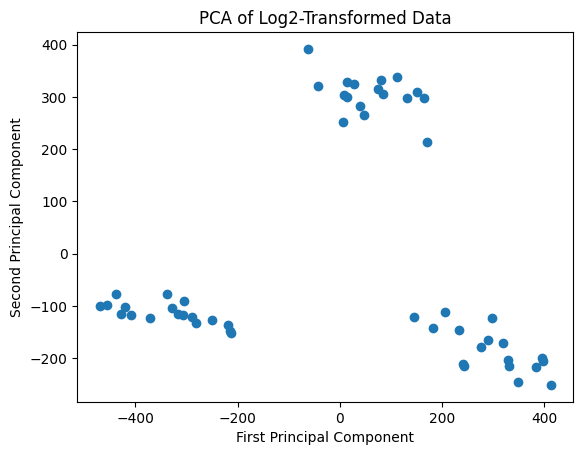

In [ ]:
# Compute the PCA with scikit-learn and plot the first two principal components with matplotlib
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=30)
pca_result = pca.fit_transform(df_log2)


# pcaresult with metadata
df2 = 

sns.plot(


plt.scatter(pca_result[:, 0], pca_result[:, 1], color=
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Log2-Transformed Data')
plt.show()

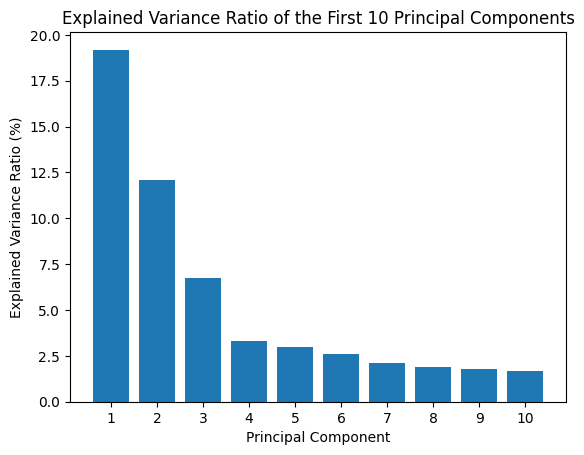

In [31]:
# Show the importance of the 10th first components (explained variance ratio)
# as a plot

explained_variance_ratio = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance_ratio) + 1)
plt.bar(components[:10], explained_variance_ratio[:10] * 100)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio (%)')
plt.title('Explained Variance Ratio of the First 10 Principal Components')
plt.xticks(components[:10])
plt.show()

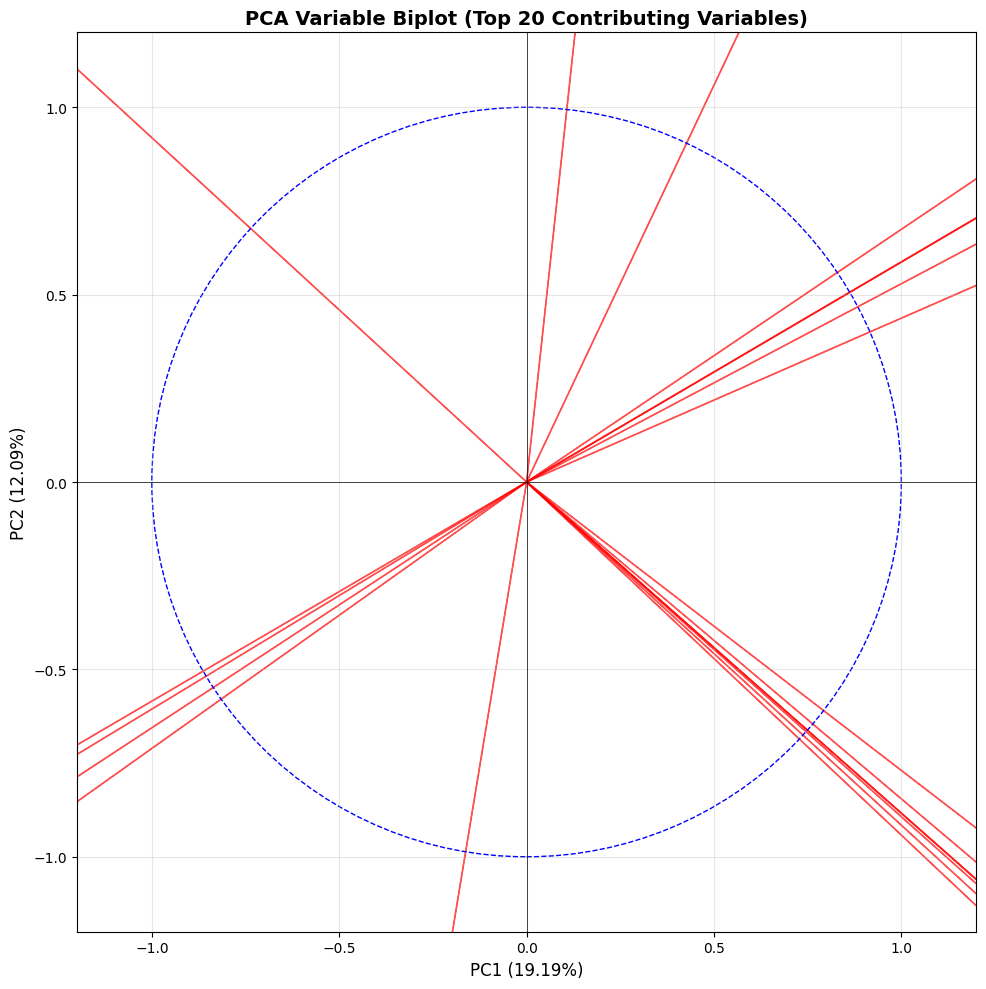

In [32]:
# Visualisation des variables PCA (similaire à fviz_pca_var en R)
# Créer un biplot des variables montrant leur contribution aux composantes principales

# Calculer les loadings (corrélations entre variables et composantes)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Créer le cercle de corrélation
fig, ax = plt.subplots(figsize=(10, 10))

# Sélectionner les top N variables les plus contributives pour la lisibilité
n_top_features = 20
feature_importance = np.sum(np.abs(loadings[:, :2]), axis=1)
top_indices = np.argsort(feature_importance)[-n_top_features:]

# Tracer les flèches pour chaque variable
for i in top_indices:
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
             head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.6)
    #ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, 
    #        df_log2.columns[i], fontsize=8, ha='center', va='center')

# Ajouter le cercle de corrélation
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=1)
ax.add_patch(circle)

# Tracer les axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# Configurer le graphique
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.set_title('PCA Variable Biplot (Top 20 Contributing Variables)', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

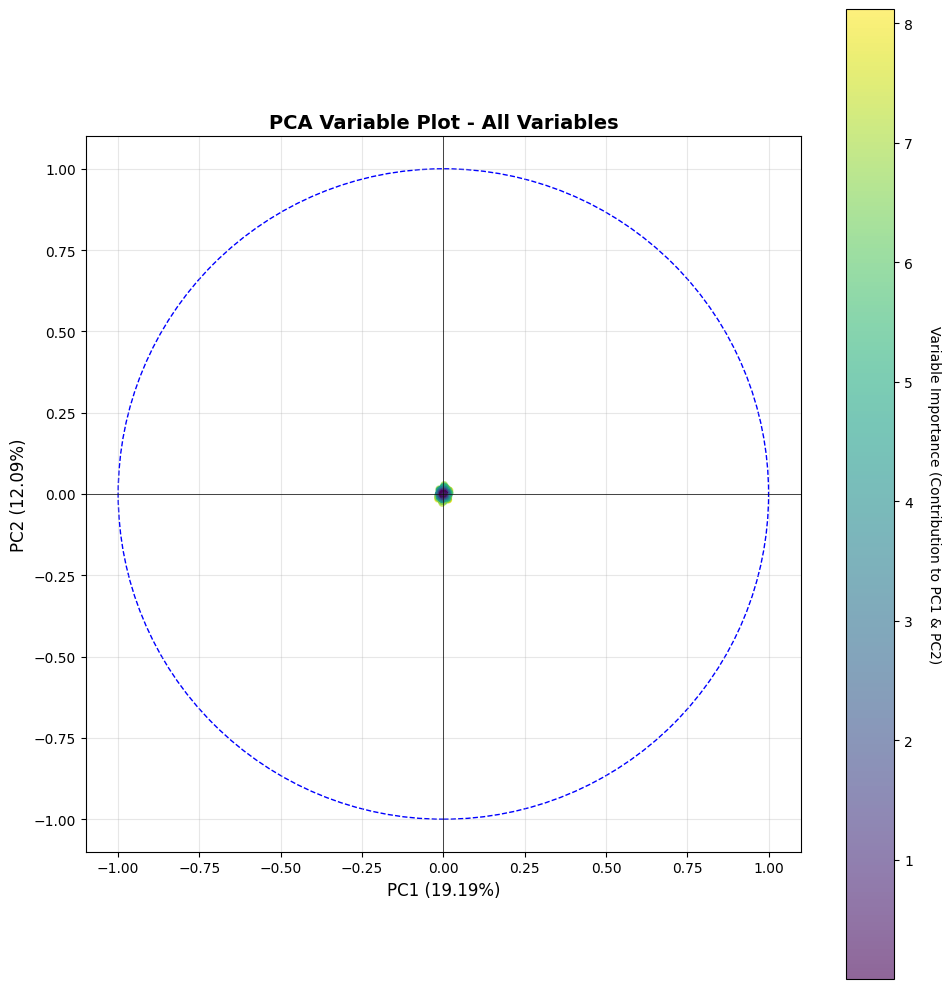

In [24]:
# Version alternative: visualisation de toutes les variables (sans labels pour éviter le chevauchement)
fig, ax = plt.subplots(figsize=(10, 10))

# Normaliser les loadings pour obtenir les corrélations
loadings_normalized = pca.components_.T

# Tracer toutes les variables comme des points
scatter = ax.scatter(loadings_normalized[:, 0], loadings_normalized[:, 1], 
                     c=feature_importance, cmap='viridis', alpha=0.6, s=20)

# Ajouter le cercle de corrélation
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=1)
ax.add_patch(circle)

# Tracer les axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# Configurer le graphique
max_val = max(abs(loadings_normalized[:, 0].max()), abs(loadings_normalized[:, 1].max()), 1) * 1.1
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.set_title('PCA Variable Plot - All Variables', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Ajouter une colorbar pour montrer l'importance des variables
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Variable Importance (Contribution to PC1 & PC2)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()